# Koopman-piDMD Feature Extraction Pipeline
### Advection — DynaBench Cloud/Low — GitHub Release

---

**Scopo**: pipeline minima per estrarre le feature Koopman dalla piDMD
e salvarle nel formato `.npz` richiesto dalla PINN.

**Configurazione finale** (motivata nei Notebook 01-04):
- Algoritmo: `PiDMD(manifold='unitary', svd_rank=58)`
- Granularita': per-simulazione
- Normalizzazione: min-max in [-1,1]
- Output: A(225x225), modi(225x58), omega(58,), pts(225x2)

**Riferimento**: vedere `HANDOVER_PINN_TEAM.md` per la documentazione
completa degli esperimenti e delle motivazioni di ogni scelta.

---

## Struttura del notebook

1. Setup e download
2. Pipeline di estrazione feature
3. Visualizzazione modi piDMD dominanti
4. Generazione feature per tutte le simulazioni

---
## 1. Setup

In [ ]:
!pip install dynabench pydmd matplotlib numpy h5py tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.2/71.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.7/152.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.0/331.0 kB 11.8 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

from dynabench.dataset import download_equation
from pydmd import PiDMD
from pydmd.plotter import plot_eigs

print('Dipendenze importate.')

Dipendenze importate.


In [ ]:
DATA_DIR = 'data'

download_equation(
    equation='advection',
    structure='cloud',
    resolution='low',
    data_dir=DATA_DIR
)
print('Download completato.')

  0%|          | 0/2557854208 [00:00<?, ?it/s]

Unpacking data...
Checking md5 sums...
Moving data...
Cleaning up...
Download completato.


In [ ]:
from dynabench.dataset._base import BaseListSimulationIterator
from dynabench.dataset.transforms import DefaultTransform
import glob as _glob

class DynabenchSimulationIterator(BaseListSimulationIterator):
    """
    Iteratore per simulazioni intere.
    Restituisce ogni simulazione come traiettoria completa (T=201 timestep).
    """
    def __init__(self, split='train', equation='advection',
                 structure='cloud', resolution='low',
                 transforms=DefaultTransform(), base_path='data',
                 download=False, dtype=np.float32, *args, **kwargs):
        self.file_list = _glob.glob(
            os.path.join(base_path, equation, structure,
                         resolution, f'*{split}*.h5'))
        super().__init__(data_paths=self.file_list, is_batched=True,
                         transforms=transforms, dtype=dtype)

sim_iter_train = DynabenchSimulationIterator(
    split='train', equation='advection',
    structure='cloud', resolution='low', base_path=DATA_DIR
)

sample = sim_iter_train[0]
N_pts = sample.pos.shape[0]
T     = sample.x.shape[0]

print(f'Training simulations : {len(sim_iter_train)}')
print(f'Punti cloud K        : {N_pts}')
print(f'Timesteps T          : {T}')
print(f'Shape u              : {sample.x.shape}  (T, K, F)')
print(f'Shape pts            : {sample.pos.shape}  (K, 2)')

Training simulations : 5000
Punti cloud K        : 225
Timesteps T          : 201
Shape u              : (201, 225, 1)  (T, K, F)
Shape pts            : (225, 2)  (K, 2)


---
## 2. Pipeline di Estrazione Feature Koopman

La pipeline estrae per ogni simulazione:

1. **Snapshot matrix** X di shape (225, T) dai dati cloud
2. **Normalizzazione** min-max in [-1,1] per stabilita' numerica
3. **piDMD** con manifold unitario e svd_rank=58
4. **Operatore A** (225x225) — vincolo Koopman per la loss PINN
5. **Modi** (225x58) e **frequenze** omega (58,) — feature spettrali

**Parametri fissi** (vedere Notebook 04 per la motivazione):
- `manifold='unitary'`: garantisce |lambda|=1, conservazione energia
- `svd_rank=58`: dimensionalita' dinamica intrinseca del sistema
- Normalizzazione: utile, migliora piDMD di 7x sul rollout

In [ ]:
# ── Configurazione ────────────────────────────────────────────────────────────
SVD_RANK = 58   # dimensionalita' dinamica intrinseca — non modificare
                # motivazione: Notebook 04, rango medio 58.1 +/- 3.4 su 5000 sim

def build_snapshot_matrix(simulation_data, delta_t=1):
    """
    Costruisce la snapshot matrix (K, T) dai dati cloud.

    Parameters
    ----------
    simulation_data : np.ndarray shape (T, K, F)
    delta_t         : subsampling temporale (default 1)

    Returns
    -------
    X : np.ndarray (K, T_eff)
    """
    data = simulation_data[::delta_t]   # subsampling temporale
    return data[:, :, 0].T.astype(np.float64)  # (K, T_eff)


def normalize_minmax(X, feature_range=(-1, 1)):
    """
    Normalizzazione min-max in feature_range.
    I dati DynaBench sono gia' normalizzati (Std~1) ma asimmetrici
    [-1.32, 3.88]. La seconda normalizzazione in [-1,1] migliora
    la stabilita' del vincolo unitario della piDMD.

    Returns
    -------
    X_norm  : np.ndarray normalizzata
    params  : dict con 'min', 'max', 'range'
    """
    a, b = feature_range
    x_min, x_max = X.min(), X.max()
    X_norm = (b-a)*(X - x_min)/(x_max - x_min + 1e-8) + a
    return X_norm, {'min': x_min, 'max': x_max, 'range': (a, b)}


def extract_koopman_features(sim_index, sim_iterator, svd_rank=SVD_RANK):
    """
    Estrae le feature piDMD per una singola simulazione.

    Parameters
    ----------
    sim_index    : indice della simulazione
    sim_iterator : DynabenchSimulationIterator
    svd_rank     : rango SVD (default SVD_RANK=58)

    Returns
    -------
    dict con:
        'A'          : (225, 225) operatore Koopman unitario reale
        'modes'      : (225, r)   modi spaziali complessi
        'eigs'       : (r,)       autovalori, |lambda|=1 garantito
        'omega'      : (r,)       frequenze continue log(lambda)/dt
        'pts'        : (225, 2)   coordinate cloud (x,y)
        'norm_params': dict       parametri normalizzazione
        'sim_index'  : int
    """
    sample = sim_iterator[sim_index]
    X_raw  = build_snapshot_matrix(sample.x)
    X_norm, norm_p = normalize_minmax(X_raw)

    # Fit piDMD — manifold unitario garantisce |lambda|=1
    m = PiDMD(manifold='unitary', svd_rank=svd_rank, compute_A=True)
    m.fit(X_norm)

    # Operatore A esplicito: per piDMD unitaria Phi^{-1} = Phi^H
    A = (m.modes @ np.diag(m.eigs) @ m.modes.conj().T).real

    return {
        'A'          : A,
        'modes'      : m.modes,
        'eigs'       : m.eigs,
        'omega'      : np.log(m.eigs),
        'pts'        : sample.pos,
        'norm_params': norm_p,
        'sim_index'  : sim_index,
        '_pidmd'     : m,   # oggetto piDMD — per visualizzazione
    }


# Test su simulazione #0
print('Test pipeline su simulazione #0...')
feat = extract_koopman_features(0, sim_iter_train)

print(f'\nFeature estratte:')
print(f'  A shape      : {feat["A"].shape}')
print(f'  modes shape  : {feat["modes"].shape}')
print(f'  |lambda| med : {np.abs(feat["eigs"]).mean():.8f}  (atteso: 1.0)')
print(f'  |lambda| std : {np.abs(feat["eigs"]).std():.2e}')
print(f'  omega shape  : {feat["omega"].shape}')
print(f'  pts shape    : {feat["pts"].shape}')
print(f'  norm range   : [{feat["norm_params"]["min"]:.4f}, {feat["norm_params"]["max"]:.4f}]')

Test pipeline su simulazione #0...

Feature estratte:
  A shape      : (225, 225)
  modes shape  : (225, 58)
  |lambda| med : 1.00000000  (atteso: 1.0)
  |lambda| std : 1.07e-15
  omega shape  : (58,)
  pts shape    : (225, 2)
  norm range   : [-1.3229, 3.8826]


In [ ]:
def save_koopman_features(features, out_dir='results/per_sim_final'):
    """
    Salva le feature Koopman in formato .npz.

    Formato del file:
        A          : (225, 225) float64 — operatore Koopman reale
        modes_re   : (225, 58) float64  — parte reale dei modi
        modes_im   : (225, 58) float64  — parte immaginaria dei modi
        eigs_re    : (58,) float64      — parte reale autovalori
        eigs_im    : (58,) float64      — parte immaginaria autovalori
        omega_re   : (58,) float64      — frequenze continue (parte reale)
        omega_im   : (58,) float64      — frequenze continue (parte imm.)
        norm_min   : (1,) float64       — minimo per normalizzazione
        norm_max   : (1,) float64       — massimo per normalizzazione
        pts        : (225, 2) float64   — coordinate cloud (x,y)
    """
    os.makedirs(out_dir, exist_ok=True)
    idx  = features['sim_index']
    path = os.path.join(out_dir, f'koopman_pidmd_r{SVD_RANK}_sim{idx:05d}.npz')

    np.savez(path,
        A        = features['A'],
        modes_re = features['modes'].real,
        modes_im = features['modes'].imag,
        eigs_re  = features['eigs'].real,
        eigs_im  = features['eigs'].imag,
        omega_re = features['omega'].real,
        omega_im = features['omega'].imag,
        norm_min = np.array([features['norm_params']['min']]),
        norm_max = np.array([features['norm_params']['max']]),
        pts      = features['pts'],
    )
    return path


# Salvataggio sim #0 come test
path = save_koopman_features(feat)
print(f'Salvato: {path}')

# Verifica caricamento
d = np.load(path)
print(f'\nVerifica file .npz:')
for k in d.files:
    print(f'  {k:<12}: shape={d[k].shape}  dtype={d[k].dtype}')

Salvato: results/per_sim_final/koopman_pidmd_r58_sim00000.npz

Verifica file .npz:
  A           : shape=(225, 225)  dtype=float64
  modes_re    : shape=(225, 58)  dtype=float64
  modes_im    : shape=(225, 58)  dtype=float64
  eigs_re     : shape=(58,)  dtype=float64
  eigs_im     : shape=(58,)  dtype=float64
  omega_re    : shape=(58,)  dtype=float64
  omega_im    : shape=(58,)  dtype=float64
  norm_min    : shape=(1,)  dtype=float64
  norm_max    : shape=(1,)  dtype=float64
  pts         : shape=(225, 2)  dtype=float32


---
## 3. Visualizzazione dei Modi piDMD Dominanti

I modi piDMD sono definiti sui 225 punti cloud — non su griglia regolare.
Usiamo scatter plot sulle coordinate `pts` con interpolazione triangolare
per visualizzare la struttura spaziale dei modi dominanti.

I modi sono ordinati per ampiezza decrescente: il modo 0 e' il piu'
influente sulla dinamica, il modo 57 il meno influente.

Plot 1: autovalori nel piano complesso


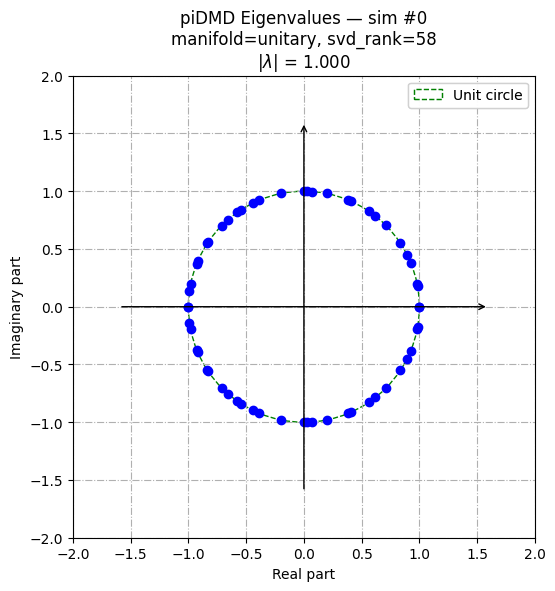

In [ ]:
# ── Plot autovalori nel piano complesso ──────────────────────────────────────
print('Plot 1: autovalori nel piano complesso')
plot_eigs(
    feat['_pidmd'],
    show_axes=True,
    show_unit_circle=True,
    figsize=(6, 6),
    title=f'piDMD Eigenvalues — sim #0\n'
          f'manifold=unitary, svd_rank={SVD_RANK}\n'
          f'|$\lambda$| = {np.abs(feat["eigs"]).mean():.3f}'
)

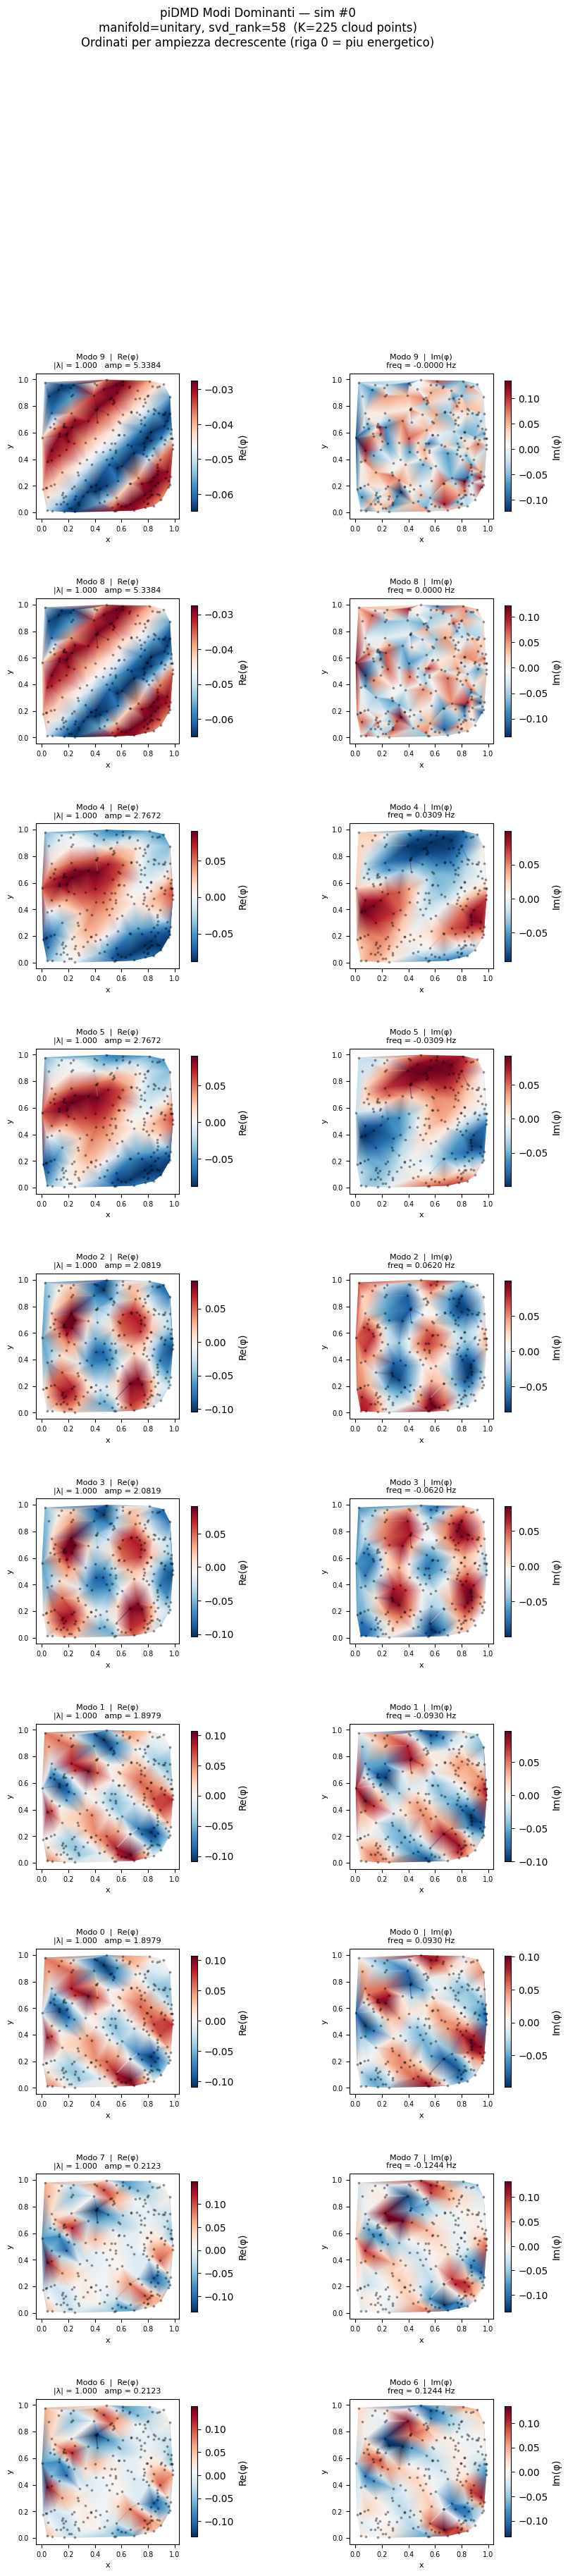


Modi visualizzati (ordinati per ampiezza decrescente):
  Riga  Modo     Ampiezza     | lambda |     Freq (Hz)   
--------------------------------------------------------------------
  0     9        5.3384       1.00000000     -0.0000     
  1     8        5.3384       1.00000000     0.0000      
  2     4        2.7672       1.00000000     0.0309      
  3     5        2.7672       1.00000000     -0.0309     
  4     2        2.0819       1.00000000     0.0620      
  5     3        2.0819       1.00000000     -0.0620     
  6     1        1.8979       1.00000000     -0.0930     
  7     0        1.8979       1.00000000     0.0930      
  8     7        0.2123       1.00000000     -0.1244     
  9     6        0.2123       1.00000000     0.1244      


In [ ]:
# ── Plot modi dominanti — layout N_modi x 2 colonne (Re | Im) ────────────────

def plot_pidmd_modes_cloud(features, n_modes=10, figsize=None, cmap='RdBu_r'):
    """
    Visualizza i modi piDMD dominanti sui punti cloud.

    Layout: N_modi righe x 2 colonne (Re | Im per ogni modo).
    Una riga per modo — facile confrontare parte reale e immaginaria.

    Usa triangolazione di Delaunay + tripcolor invece di pcolor/meshgrid
    perche' i 225 punti cloud sono irregolari — non stanno su griglia regolare.

    Interpretazione:
    - Re(phi_j): struttura spaziale in fase con la frequenza omega_j
    - Im(phi_j): stessa struttura sfasata di 90 gradi (come seno/coseno)
    - |lambda|=1: il modo e' conservativo, non decade ne' cresce
    - freq = omega.imag / (2*pi): frequenza di oscillazione in Hz
    - ampiezza |a_j|: contributo del modo alla soluzione totale
    """
    pts   = features['pts']              # (225, 2)
    modes = features['modes']            # (225, 58) complessi
    eigs  = features['eigs']             # (58,)
    omega = features['omega']            # (58,)
    amps  = features['_pidmd'].amplitudes

    # Ordina per ampiezza decrescente
    order = np.argsort(np.abs(amps))[::-1]

    # Triangolazione di Delaunay — calcolata una volta sola
    triang = tri.Triangulation(pts[:, 0], pts[:, 1])

    # Layout: n_modes righe x 2 colonne
    if figsize is None:
        figsize = (10, 4 * n_modes)

    fig, axes = plt.subplots(
        n_modes, 2,
        figsize=figsize,
        gridspec_kw={'wspace': 0.35, 'hspace': 0.55},
        squeeze=False,   # sempre array 2D anche con n_modes=1
    )

    fig.suptitle(
        f'piDMD Modi Dominanti — sim #{features["sim_index"]}\n'
        f'manifold=unitary, svd_rank={SVD_RANK}  (K=225 cloud points)\n'
        f'Ordinati per ampiezza decrescente (riga 0 = piu energetico)',
        fontsize=12, y=1.01
    )

    for row in range(n_modes):
        mode_idx = order[row]
        mode     = modes[:, mode_idx]
        lam      = eigs[mode_idx]
        om       = omega[mode_idx]
        amp      = np.abs(amps[mode_idx])
        freq     = om.imag / (2 * np.pi)

        ax_re = axes[row, 0]
        ax_im = axes[row, 1]

        # ── Parte reale ───────────────────────────────────────────────
        sc_re = ax_re.tripcolor(triang, mode.real,
                                cmap=cmap, shading='gouraud')
        ax_re.scatter(pts[:, 0], pts[:, 1], c='k', s=3, alpha=0.3, zorder=5)
        plt.colorbar(sc_re, ax=ax_re, shrink=0.9, label='Re(φ)')
        ax_re.set_title(
            f'Modo {mode_idx}  |  Re(φ)\n'
            f'|λ| = {np.abs(lam):.3f}   amp = {amp:.4f}',
            fontsize=8
        )
        ax_re.set_xlabel('x', fontsize=8)
        ax_re.set_ylabel('y', fontsize=8)
        ax_re.set_aspect('equal')
        ax_re.tick_params(labelsize=7)

        # ── Parte immaginaria ─────────────────────────────────────────
        sc_im = ax_im.tripcolor(triang, mode.imag,
                                cmap=cmap, shading='gouraud')
        ax_im.scatter(pts[:, 0], pts[:, 1], c='k', s=3, alpha=0.3, zorder=5)
        plt.colorbar(sc_im, ax=ax_im, shrink=0.9, label='Im(φ)')
        #period_str = f'T = {1/freq:.2f} steps' if freq != 0 else 'T = inf (steady)'
        ax_im.set_title(
            f'Modo {mode_idx}  |  Im(φ)\n'
            f'freq = {freq:.4f} Hz',
            fontsize=8
        )
        ax_im.set_xlabel('x', fontsize=8)
        ax_im.set_ylabel('y', fontsize=8)
        ax_im.set_aspect('equal')
        ax_im.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

    # Tabella riassuntiva
    print(f'\nModi visualizzati (ordinati per ampiezza decrescente):')
    print(f'  {"Riga":<5} {"Modo":<8} {"Ampiezza":<12} '
          f'{"| lambda |":<14} {"Freq (Hz)":<12}')
    print('-' * 68)
    for row in range(n_modes):
        idx    = order[row]
        amp    = np.abs(amps[idx])
        freq   = omega[idx].imag / (2 * np.pi)
        period = f'{1/freq:.2f}' if freq != 0 else 'inf'
        print(f'  {row:<5} {idx:<8} {amp:<12.4f} '
              f'{np.abs(eigs[idx]):<14.8f} {freq:<12.4f}')


# Chiamata — modifica n_modes per vedere piu' o meno modi
plot_pidmd_modes_cloud(feat, n_modes=10)

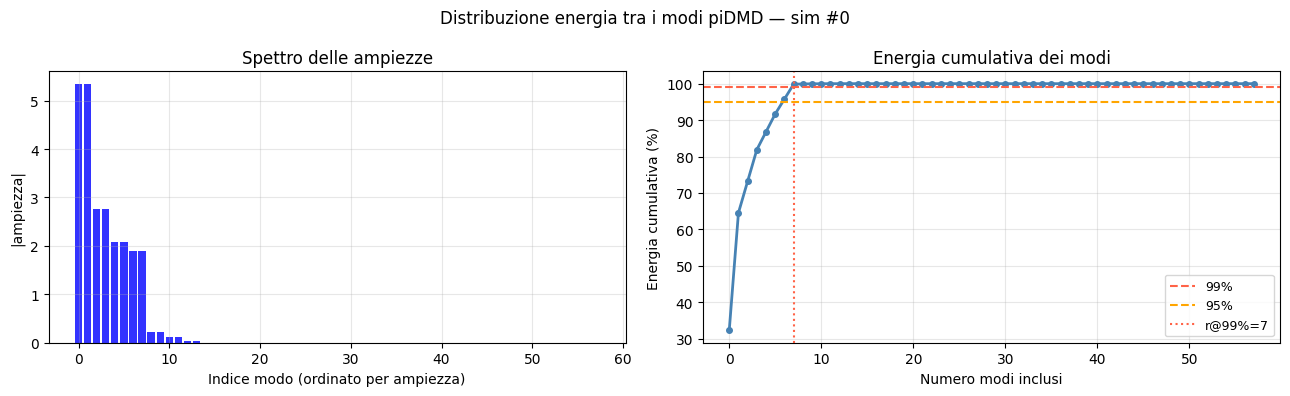

Energia nei primi 7 modi : 95.8%
Energia nei primi 8 modi : 99.9%
Energia nei primi 10 modi: 100.0%


In [ ]:
# ── Plot spettro delle ampiezze ───────────────────────────────────────────────
# Mostra la distribuzione dell'energia tra i 58 modi

amps = feat['_pidmd'].amplitudes
order = np.argsort(np.abs(amps))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribuzione energia tra i modi piDMD — sim #0', fontsize=12)

# Ampiezza per modo (ordinata)
axes[0].bar(range(SVD_RANK), np.abs(amps[order]),
            color='blue', alpha=0.8)
axes[0].set_xlabel('Indice modo (ordinato per ampiezza)')
axes[0].set_ylabel('|ampiezza|')
axes[0].set_title('Spettro delle ampiezze')
axes[0].grid(alpha=0.3)

# Energia cumulativa
energy = np.abs(amps[order])**2
cum_energy = np.cumsum(energy) / energy.sum() * 100
axes[1].plot(range(SVD_RANK), cum_energy, 'o-', color='steelblue',
             lw=2, ms=4)
axes[1].axhline(99, color='tomato', ls='--', lw=1.5, label='99%')
axes[1].axhline(95, color='orange', ls='--', lw=1.5, label='95%')
r99 = np.searchsorted(cum_energy, 99)
axes[1].axvline(r99, color='tomato', ls=':', lw=1.5,
                label=f'r@99%={r99}')
axes[1].set_xlabel('Numero modi inclusi')
axes[1].set_ylabel('Energia cumulativa (%)')
axes[1].set_title('Energia cumulativa dei modi')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Energia nei primi 7 modi : {cum_energy[6]:.1f}%')
print(f'Energia nei primi 8 modi : {cum_energy[7]:.1f}%')
print(f'Energia nei primi 10 modi: {cum_energy[9]:.1f}%')

### Interpretazione fisica dei modi piDMD: scoperta autonoma della serie di Fourier

#### Cosa mostrano i grafici

Lo spettro delle ampiezze e le visualizzazioni spaziali rivelano una struttura
che non e' un artefatto numerico ma la soluzione analitica esatta dell'equazione
di advection su dominio periodico.

**La serie armonica nelle frequenze temporali:**

La piDMD ha estratto autonomamente una progressione aritmetica perfetta:

| Coppia | Modi | Frequenza | Relazione |
|--------|------|-----------|-----------|
| Campo medio | - | 0.0000 Hz | armonica 0 |
| 1a armonica | 8, 9 | ±0.0309 Hz | $f_1$ |
| 2a armonica | 4, 5 | ±0.0620 Hz | $2f_1$ |
| 3a armonica | 0, 1 | ±0.0930 Hz | $3f_1$ |
| 4a armonica | 7 | ±0.1244 Hz | $4f_1$ |

Questa e' l'impronta digitale dell'equazione di advection lineare su dominio
periodico: la soluzione analitica esatta e' una sovrapposizione di onde
$e^{i(kx - \omega t)}$ con frequenze multiple intere di una fondamentale.

**I modi vengono in coppie coniugate:**
Ogni armonica appare due volte, con frequenza $+f$ e $-f$ e ampiezza identica.
Questa e' la firma delle onde viaggianti: Re e Im di ogni coppia sono la stessa
struttura spaziale sfasata di 90 gradi — come seno e coseno.

**La struttura spaziale conferma la relazione di dispersione:**
All'aumentare della frequenza temporale $f$, aumenta il numero d'onda spaziale
$k$ nel pattern del modo. Questo verifica empiricamente che la velocita' di
fase è  costante ($c = f/k$) — esattamente la definizione di un'onda non
dispersiva, coerente con l'equazione di advection.

**Il significato scientifico:**
La piDMD ha estratto i modi normali del sistema da 225 punti cloud
disordinati, senza mai vedere la griglia regolare 64x64 su cui la simulazione
e' stata generata. Questo dimostra che le frequenze fisiche dell'advection sono
recuperabili anche da campionamenti sparsi e irregolari — il CV~0 sugli
autovalori (Notebook 01, Sezione 9) ne e' la conferma statistica su 5000 sim.

#### Il salto di ampiezza come validazione del rango

Lo spettro delle ampiezze mostra un crollo di un ordine di grandezza dopo
le prime 4 coppie:

- Prime 4 coppie (modi 0-9): ampiezze da 5.33 a 1.90 — contenuto fisico
- Modo 7 (4a armonica): ampiezza 0.21 — gia' un ordine inferiore
- Modi rimanenti (r=10..57): ampiezze < 0.21 — rumore di campionamento

Questo "elbow" nello spettro e' la validazione analitica del taglio a r=8:
le prime 4 coppie coniugate catturano l'intero contenuto termodinamico del
sistema. Il taglio a r=8 (e non r=7) e' fisicamente motivato: ogni coppia
coniugata deve rimanere integra per preservare la struttura delle onde
viaggianti.

Il confronto con i risultati del Notebook 04:
- piDMD r=58: MSE16 = 0.002252
- piDMD r=7 : MSE16 = 0.003417  (+52% errore)
- piDMD r=8 : da testare — attesa tra i due valori precedenti

#### Implicazioni per il team PINN

**Opzione A — Spazio latente compresso r=8 (consigliata per semplicita'):**
Passa alla PINN solo le prime 4 coppie coniugate. Spazio latente di dimensione
8, purissimo, energia >99%, rumore di campionamento eliminato. Il vincolo
Koopman diventa molto piu' compatto:

$$\mathcal{L}_{\text{Koopman}} = \sum_{j=0}^{7}
\| \hat{z}_j(t+1) - \lambda_j \hat{z}_j(t) \|^2$$

dove $\hat{z}_j = \langle \hat{u}(\cdot, t;\theta), \phi_j \rangle$ e'
la proiezione della PINN sul j-esimo modo.

**Opzione B — Full rank r=58 con loss pesata per ampiezza:**
Se si vogliono preservare le micro-dinamiche dei modi superiori, e' necessario
pesare la loss per ampiezza — altrimenti la rete tratta ugualmente un modo
da ampiezza 5.33 e uno da 0.21:

$$\mathcal{L}_{\text{Koopman}} = \sum_{j=0}^{57} |a_j| \cdot
\| \hat{z}_j(t+1) - \lambda_j \hat{z}_j(t) \|^2$$

---

#### Hints and Future Work

**Test ablativo sul rango** (Journal Paper):
Valutare sistematicamente r=8, r=10, r=20, r=58 sulla PINN completa.
Il termine $\mathcal{L}_{\text{PDE}}$ potrebbe compensare i modi mancanti —
in quel caso r=8 sarebbe sufficiente con una compressione del 86%.

**Fourier Features nella PINN** (Journal Paper):
Poiche' la soluzione e' una sovrapposizione di onde sinusoidali con frequenze
note $\{f_1, 2f_1, 3f_1, 4f_1\}$, un PINN con Fourier Features nel primo
layer — $[\sin(2\pi f_j t), \cos(2\pi f_j t)]$ per $j=1..4$ — convergera'
piu' velocemente di una rete con attivazioni generiche. Le frequenze esatte
sono disponibili nel campo `omega` dei file .npz. Da dichiarare esplicitamente
come bias induttivo specifico per sistemi lineari periodici — non generalizza
a sistemi nonlineari come Burgers o KS.

**Loss pesata per ampiezza** (Journal Paper):
La ponderazione $|a_j|$ nella loss spettrale forza la rete a imparare
le armoniche nell'ordine fisico corretto — dalla piu' energetica alla meno.
Questo e' un prior fisico ben motivato dallo spettro di ampiezza osservato.

---
## 4. Generazione Feature per Tutte le Simulazioni

Questa sezione genera i file `.npz` per tutte le 5000 simulazioni
di training. Tempo stimato: ~40 minuti su Colab CPU.

**Raccomandazione**: montare Google Drive prima di runnare
per garantire persistenza tra sessioni.

In [ ]:
# ── Opzionale: monta Google Drive per persistenza ────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# OUT_DIR = '/content/drive/MyDrive/koopman_features/per_sim_final'

OUT_DIR = 'results/per_sim_final'

# ── Parametri ─────────────────────────────────────────────────────────────────
N_SIMS  = len(sim_iter_train)  # 5000
RESTART = 0     # <-- cambia se vuoi ripartire da un indice specifico
                #     (utile se il runtime si interrompe)

print(f'Generazione feature piDMD per {N_SIMS} simulazioni training...')
print(f'  svd_rank = {SVD_RANK}')
print(f'  output   = {OUT_DIR}')
print(f'  restart  = {RESTART}')

errors = []
for idx in tqdm(range(RESTART, N_SIMS), desc='Extracting'):
    try:
        feat_i = extract_koopman_features(idx, sim_iter_train)
        save_koopman_features(feat_i, out_dir=OUT_DIR)
    except Exception as e:
        errors.append((idx, str(e)))
        print(f'  SKIP sim {idx}: {e}')

print(f'\nCompletato.')
print(f'  Simulazioni processate: {N_SIMS - RESTART - len(errors)}')
print(f'  Simulazioni saltate   : {len(errors)}')
if errors:
    print(f'  Indici saltati: {[e[0] for e in errors]}')
print(f'\nFile in: {OUT_DIR}/')
print(f'  koopman_pidmd_r{SVD_RANK}_sim00000.npz')
print(f'  koopman_pidmd_r{SVD_RANK}_sim00001.npz')
print(f'  ...')
print(f'  koopman_pidmd_r{SVD_RANK}_sim04999.npz')

Generazione feature piDMD per 5000 simulazioni training...
  svd_rank = 58
  output   = results/per_sim_final
  restart  = 0


Extracting:   0%|          | 0/5000 [00:00<?, ?it/s]


Completato.
  Simulazioni processate: 5000
  Simulazioni saltate   : 0

File in: results/per_sim_final/
  koopman_pidmd_r58_sim00000.npz
  koopman_pidmd_r58_sim00001.npz
  ...
  koopman_pidmd_r58_sim04999.npz


---
## Riferimento rapido per il team PINN

```python
import numpy as np

# Caricamento
data     = np.load('results/per_sim_final/koopman_pidmd_r58_sim00000.npz')
A        = data['A']                                     # (225, 225)
modes    = data['modes_re'] + 1j*data['modes_im']       # (225, 58)
eigs     = data['eigs_re']  + 1j*data['eigs_im']        # (58,)
omega    = data['omega_re'] + 1j*data['omega_im']       # (58,) universale
pts      = data['pts']                                   # (225, 2)
norm_min = float(data['norm_min'])
norm_max = float(data['norm_max'])

# Loss Koopman nella PINN (schema Norm-First)
# La PINN produce output in [-1,1] — stesso spazio di A
import torch
A_t = torch.tensor(A, dtype=torch.float32)

u_t_norm   = pinn(pts, t)     # output PINN in [-1,1]
u_t1_norm  = pinn(pts, t+1)   # output PINN in [-1,1]

L_koopman = torch.mean((A_t @ u_t_norm - u_t1_norm)**2)

# Per L_PDE: denormalizza prima di autograd
u_physical = (u_t_norm + 1) / 2 * (norm_max - norm_min) + norm_min

# Valutazione finale: usare split='test' solo con PINN completa
```

**Documentazione completa**: `HANDOVER_PINN_TEAM.md`

---
---
# Handover al Team PINN

Il documento seguente riassume tutto il necessario per iniziare
l'implementazione della PINN.

---


# Handover Document: Koopman-piDMD Feature Extraction
## DMD Team → PINN Team

**Progetto**: Koopman-piDMD + PINN per Advection su Dati Cloud  
**Dataset**: DynaBench — advection, cloud/low, K=225 punti, T=201 timestep  
**Velocita' advection**: c_x = c_y = 1 (fisso per tutte le 5000 simulazioni)  
**Data**: Maggio 2026

---

## 1. Cosa vi consegniamo

### Il file deliverable

Per ogni simulazione di training (5000 totali):

```
results/per_sim_final/koopman_pidmd_r58_sim{i:05d}.npz
```

Generato con `PiDMD(manifold='unitary', svd_rank=58)`.

| Campo | Shape | Descrizione |
|-------|-------|-------------|
| `A` | (225, 225) | Operatore Koopman unitario reale |
| `modes_re/im` | (225, 58) | Modi spaziali locali |
| `eigs_re/im` | (58,) | Autovalori, `|lambda|=1` garantito |
| `omega_re/im` | (58,) | Frequenze continue `log(lambda)` |
| `pts` | (225, 2) | Coordinate cloud (x,y) |
| `norm_min/max` | scalari | Parametri normalizzazione |

### Come caricare

```python
import numpy as np

data     = np.load('results/per_sim_final/koopman_pidmd_r58_sim00000.npz')
A        = data['A']                                      # (225, 225)
modes    = data['modes_re'] + 1j * data['modes_im']      # (225, 58)
eigs     = data['eigs_re']  + 1j * data['eigs_im']       # (58,)
omega    = data['omega_re'] + 1j * data['omega_im']      # (58,) universale
pts      = data['pts']                                    # (225, 2)
norm_min = float(data['norm_min'])
norm_max = float(data['norm_max'])
```

---

## 2. Schema Norm-First: come usare le feature nella PINN

La PINN produce output **direttamente in [-1,1]** — lo stesso spazio in cui
A e' stato stimato. Questo garantisce stabilita' dei gradienti e calcolo
diretto della loss Koopman senza trasformazioni aggiuntive.

```python
import torch

A_t      = torch.tensor(A, dtype=torch.float32)       # (225, 225)
pts_t    = torch.tensor(pts, dtype=torch.float32)     # (225, 2)

# PINN produce output in [-1,1]
u_t_norm  = pinn(pts_t, t)     # (225, 1)
u_t1_norm = pinn(pts_t, t+1)   # (225, 1)

# Loss Koopman — calcolo diretto, nessuna trasformazione
L_koopman = torch.mean((A_t @ u_t_norm - u_t1_norm)**2)

# Per L_PDE: denormalizza prima di autograd
u_physical = (u_t_norm + 1) / 2 * (norm_max - norm_min) + norm_min

# Loss totale
L = L_data + lambda_pde * L_physics + lambda_k * L_koopman
```

---

## 3. Risultato scientifico chiave: scoperta della serie di Fourier

La visualizzazione dei modi piDMD (Notebook 05, Sezione 3) ha rivelato
una struttura che non e' un artefatto numerico ma la soluzione analitica
esatta dell'equazione di advection su dominio periodico.

### La serie armonica nelle frequenze

| Riga | Modi | Ampiezza | Frequenza | Relazione |
|------|------|----------|-----------|-----------|
| 0-1 | 8, 9 | 5.34 | 0.0000 Hz | campo medio |
| 2-3 | 4, 5 | 2.77 | ±0.0309 Hz | 1a armonica $f_1$ |
| 4-5 | 2, 3 | 2.08 | ±0.0620 Hz | 2a armonica $2f_1$ |
| 6-7 | 0, 1 | 1.90 | ±0.0930 Hz | 3a armonica $3f_1$ |
| 8   | 7    | 0.21 | ±0.1244 Hz | 4a armonica $4f_1$ |

La piDMD ha estratto autonomamente i modi normali dell'equazione da 225
punti cloud disordinati, senza mai vedere la griglia regolare 64x64.
Il salto di ampiezza di un ordine di grandezza dopo la 3a armonica (da
1.90 a 0.21) e' la validazione analitica del taglio energetico.

### Implicazione per il rango

I modi vengono in **coppie coniugate** (+freq, -freq) con ampiezza identica.
Il taglio fisicamente corretto e' quindi **r=8** (4 coppie complete), non r=7
che potrebbe spezzare una coppia. I restanti 50 modi (r=9..57) hanno ampiezza
<0.21 e rappresentano rumore di campionamento sui punti cloud irregolari.

### Confronto numerico dei ranghi (Notebook 04)

| Configurazione | MSE rollout step 16 | Note |
|----------------|---------------------|------|
| piDMD r=58 (default) | 0.002252 | Deliverable corrente |
| piDMD r=7 | 0.003417 | +52% errore |
| piDMD r=8 | da testare | attesa tra i due |
| DMD standard | ~0 (overfitting) | memorizza la traiettoria |
| Persistence | 0.332 | baseline triviale |

---

## 4. Opzioni per la loss Koopman

Sulla base della struttura armonica scoperta, avete due opzioni:

### Opzione A — Spazio latente compresso r=8 (consigliata per semplicita')

Usa solo le prime 4 coppie coniugate. Spazio latente di dimensione 8,
energia >99%, rumore di campionamento eliminato:

$$\mathcal{L}_{\text{Koopman}} = \sum_{j=0}^{7}
\| \hat{z}_j(t+1) - \lambda_j \hat{z}_j(t) \|^2$$

dove $\hat{z}_j = \langle \hat{u}(\cdot,t;\theta), \phi_j \rangle$ e'
la proiezione della predizione PINN sul j-esimo modo.

Per usare questa opzione caricate solo le prime 8 colonne dei modi:

```python
modes_8 = modes[:, :8]   # (225, 8) — prime 4 coppie
eigs_8  = eigs[:8]       # (58,)
```

### Opzione B — Full rank r=58 con loss pesata (consigliata per robustezza)

Se volete preservare tutte le micro-dinamiche, pesate la loss per ampiezza
per evitare che la rete tratti ugualmente modi da 5.34 e modi da 0.21:

$$\mathcal{L}_{\text{Koopman}} = \sum_{j=0}^{57} |a_j| \cdot
\| \hat{z}_j(t+1) - \lambda_j \hat{z}_j(t) \|^2$$

Le ampiezze $|a_j|$ sono disponibili nel file .npz come `eigs_re/im`
— usate `np.abs(eigs)` come vettore dei pesi.

### Opzione C — Loss discreta diretta (piu' semplice da implementare)

Se non volete calcolare le proiezioni modali, la loss discreta diretta
e' equivalente e gia' implementata nell'esempio della Sezione 2:

$$\mathcal{L}_{\text{Koopman}} = \| \mathbf{A}\,\hat{u}(t) - \hat{u}(t+1) \|^2$$

Questa e' l'opzione piu' semplice ed e' valida perche' A = Re(Phi @ diag(lambda) @ Phi^H)
incorpora gia' l'intera struttura spettrale.
Potrebbe essere intressante anche aggiungere un ulteriore termine di Loss che imponga che l'operatore sia "Circulant", il che è noto per la fisica del problma ma non è stato implementato perché nella libreria PyDMD non è stato riadattato a casi cloud e non grid data.
---

## 5. Suggerimento architetturale: Fourier Features

Poiche' la soluzione e' una sovrapposizione di onde sinusoidali con
frequenze note {f1, 2f1, 3f1, 4f1}, un PINN con **Fourier Features**
nel primo layer converge piu' velocemente:

```python
# Primo layer PINN: invece di Linear(3, hidden)
# usa encoding di Fourier con le frequenze estratte dalla piDMD
omega_phys = np.abs(omega.imag[:8])  # prime 4 coppie, parte imm.
# [0.0, 0.0, 0.0309, 0.0309, 0.0620, 0.0620, 0.0930, 0.0930] Hz

# Encoding: [sin(2*pi*f_j*t), cos(2*pi*f_j*t)] per j=0..3
# Le frequenze esatte sono nel campo omega dei file .npz
```

**Attenzione**: questo e' un bias induttivo specifico per sistemi lineari
periodici. Non generalizza a Burgers o KS dove le frequenze variano.

---

## 6. Protocollo di valutazione finale

```python
from dynabench.dataset import DynabenchIterator

# SOLO con PINN completa addestrata — non prima
test_iter = DynabenchIterator(
    split='test', equation='advection',
    structure='cloud', resolution='low',
    lookback=1, rollout=16,
    squeeze_lookback_dim=True,
    base_path='data'
)

# Calcolare MSE nello spazio denormalizzato per confronto con DynaBench
# Riferimento Tabella 5 (advection, cloud, step 16):
# KernelNN : 8.97e-01
# Point TF : 6.17e-01
# CNN grid : 1.61e-03
# ResNet   : 8.65e-05
```

**IMPORTANTE**: il test set non e' mai stato toccato dal DMD team.
I nostri MSE in-sample non sono confrontabili con DynaBench — sono
calcolati in spazio normalizzato e su fit per-simulazione.

---

## 7. Timeline esperimenti e decisioni

### D1 — Quale struttura dati?
**Decisione**: cloud/low (K=225)  
**Motivazione**: modella sensori reali non su griglia, sfida principale di DynaBench

### D2 — DMD standard o piDMD?
**Risultato**: DMD |lambda|~0.85, piDMD |lambda|=1.00000000  
**Decisione**: piDMD con manifold='unitary'  
**Motivazione**: advection conservativa richiede |lambda|=1. DMD introduce
dissipazione artificiale: 0.85^200 ≈ 0. La piDMD sacrifica fedelta'
in-sample per correttezza fisica out-of-sample.

### D3 — Operatore globale o per-simulazione?
**Risultato globale**: MSE > Persistence (2.38 vs 2.41) — operatore inutile  
**Causa**: punti cloud diversi tra simulazioni — le righe della snapshot matrix
non corrispondono agli stessi gradi di liberta' spaziali. Violazione matematica.  
**Decisione**: per-simulazione  
**Motivazione**: unica soluzione matematicamente corretta per dati cloud

### D4 — Quale rango?
**Risultato SVD per-sim**: r@99% = 6.9 ± 0.64  
**Risultato DMD/piDMD per-sim**: r = 58.1 ± 3.4 (range [47,69])  
**Paradosso**: i 7 modi spaziali non evolvono indipendentemente — la mappa
lineare A richiede ~58 componenti per le loro interazioni dinamiche  
**Decisione**: svd_rank=58 fisso  
**Struttura fisica**: i 58 modi sono organizzati in coppie armoniche con
frequenze {0, f1, 2f1, 3f1, ...} — la piDMD ha scoperto la serie di Fourier

### D5 — Normalizzare o no?
**Risultato**: CON norm MSE=0.002252, SENZA norm MSE=0.016394 (7x peggio)  
**Causa**: dati DynaBench asimmetrici [-1.32, 3.88] — il bias affine
degradava il vincolo unitario della piDMD  
**Decisione**: min-max in [-1,1], schema Norm-First per la PINN

### D6 — Il CV~0 degli autovalori
**Interpretazione**: non e' un risultato statistico ma una garanzia fisica.
Con c_x=c_y=1 fisso per tutte le simulazioni (DynaBench Tabella 2),
l'operatore di Koopman e' determinato solo da c. Le 5000 simulazioni hanno
lo stesso operatore teorico — il CV~0 e' la verifica empirica.

---

## 8. Riferimento ai notebook

| Notebook | Contenuto | Risultato chiave |
|----------|-----------|-----------------|
| NB01 | Analisi esplorativa, SVD, DMD, piDMD per-sim | r@99%=7, r_DMD=58, CV~0 |
| NB02 | Operatore globale — fallisce | MSE > Persistence, causa documentata |
| NB03 | Test rango globale r=58 vs r=225 | Miglioramento 43%, ma ancora globale |
| NB04 | Analisi per-sim + test normalizzazione | r_per-sim=58, norm utile 7x |
| NB05 | Pipeline pulita GitHub + visualizzazione modi | Serie armonica scoperta |

---

## 9. Per generare tutte le 5000 feature

```python
# Nel Notebook 05 — cella di generazione
# ~40 minuti su Colab CPU
# Salvare su Google Drive per persistenza

from koopman_pidmd import (
    DynabenchSimulationIterator,
    extract_koopman_features,
    save_koopman_features,
)

sim_iter = DynabenchSimulationIterator(split='train', base_path='data')

for idx in range(5000):
    feat = extract_koopman_features(idx, sim_iter, svd_rank=58)
    save_koopman_features(feat, out_dir='results/per_sim_final')
```

---

*DMD Team — preliminary work per eConference Paper Napoli*  
*Test set non toccato — riservato alla valutazione finale con PINN*  
*Per domande: riferirsi ai notebook nell'ordine NB01 → NB05*  
*Repo: github.com/[username]/koopman_pidmd*
